MOUNT GOOGLE DRIVE,
And make a copy of our data that is available at:
https://drive.google.com/drive/folders/10BE1MqYS6C0GrExK3MrMJqkY0C2szWOg


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
%pip install netCDF4

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 64.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 71.9 MB/s eta 0:00:00


# Analyze Grading Dates Tolerance
We noticed that not all grading dates for each specific record is not perfectly 7 days back, sometimes 6 or 8, below demonstrates this, So we will allow a tolerance when getting the prevvarde(Previous Pest Value) and prevvutvecklinstadium(Previous Crop Growth)

In [ ]:
import json
from datetime import datetime, timedelta

#filter
GRODA_FILTER = "Höstvete"
PEST_FILTER = "Bladfläcksvampar"

#load the local jordbruksverket_data
with open('/content/drive/MyDrive/MLProject/jordbruksverket_data.json', 'r', encoding='utf-8') as f:
    data = json.load(f, strict=False)

total_records_with_events = 0
total_date_pairs = 0
deviation_count = 0
deviation_details = []

#process each record
for record in data:
    if record.get("groda") != GRODA_FILTER:
        continue

    record_id = record.get("recordId")
    event_dates = []

    #extract grading event dates for the specified PEST_FILTER
    for event in record.get('graderingstillfalleList', []):
        date_str = event.get("graderingsdatum")
        try:
            date_obj = datetime.strptime(date_str, "%Y-%m-%d").date()
        except Exception:
            continue

        #check if any grading in the event has the specified PEST_FILTER
        if any(grading.get("skadegorare") == PEST_FILTER for grading in event.get("graderingList", [])):
            event_dates.append(date_obj)

    #only process records with at least two valid events
    if len(event_dates) < 2:
        continue

    total_records_with_events += 1
    event_dates.sort()

    #check each consecutive pair for exactly ±1 day deviation from 7 days
    for i in range(1, len(event_dates)):
        prev_date = event_dates[i - 1]
        curr_date = event_dates[i]
        diff_days = (curr_date - prev_date).days
        total_date_pairs += 1

        if diff_days == 6 or diff_days == 8:
            deviation_count += 1
            deviation_details.append({
                "recordId": record_id,
                "previous_date": prev_date.isoformat(),
                "current_date": curr_date.isoformat(),
                "difference_days": diff_days
            })

#output
print("Total records with at least two grading events:", total_records_with_events)
print("Total consecutive grading date pairs checked:", total_date_pairs)
print("Total deviations (difference exactly 6 or 8 days):", deviation_count)

if deviation_details:
    print("\nDeviation Details:")
    for detail in deviation_details:
        print(detail)


FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/MLProject/jordbruksverket_data.json'

#1 Get the local features from jordburksverket

Here we load jordbruksverkets data, Get all unique dates and their lon&lat, varde, and other feature data (FILTERED FOR A SPECIFIC CROP & PEST) IN order for us to later extract the precise weather data(The prediction data 7 days back from the target graderingsdatum) and combine the features that exist in jordbruksverkets data

We also make sure to get the previous varde and previous utvecklingsstadium for each record so our model can make a more informed guess

Tolerance will also be added when getting prevvarde and prevvutvecklingsstadium

In [ ]:
import json
from datetime import datetime, timedelta
from pyproj import Transformer

# filter settings
#GRODA_FILTER = ["Höstvete","Havre","Vårvete","Rågvete"]
#PEST_FILTER = "Bladfläcksvampar"

#lets try for an insect now
GRODA_FILTER = ['Höstvete', 'Havre', 'Vårvete', 'Rågvete']
PEST_FILTER = "Bladfläcksvampar"

# transform from SWEREF99 TM (EPSG:3006) to WGS84 (EPSG:4326)
transformer = Transformer.from_crs("EPSG:3006", "EPSG:4326", always_xy=True)

with open('/content/drive/MyDrive/MLProject/jordbruksverket_data.json', 'r', encoding='utf-8') as f:
    data = json.load(f, strict=False)


results = []

# process each record
for record in data:
    # only process records with the desired groda value
    if record.get("groda") not in GRODA_FILTER:
        continue

    recordId = record.get('recordId')
    ekologisk = record.get('ekologisk')
    # extract "forfrukt" from the record
    # forfrukt = record.get("forfrukt", "") not used now
    # initial developmentPhase (this may be overwritten per event)
    developmentPhase = record.get("utvecklingsstadium")

    # convert coordinates using pyproj transformer
    lat = record.get("latitud")
    lon = record.get("longitud")
    jordart = record.get("jordart")
    sgu_jordart = record.get("jordart_sgu")

    #print(jordart)
    #time.sleep(9999)

    if lat is None or lon is None:
        continue
    lon_deg, lat_deg = transformer.transform(float(lon), float(lat))

    # build dictionaries for unique events (by grading date) and for previous event lookup.
    unique_events = {}
    grading_lookup = {}

    for event in record.get('graderingstillfalleList', []):
        date_str = event.get('graderingsdatum')
        event_developmentPhase = event.get("utvecklingsstadium")
        try:
            date_obj = datetime.strptime(date_str, "%Y-%m-%d").date()
        except Exception:
            continue

        #process each grading in the event and check the "skadegorare" field
        for gradering in event.get('graderingList', []):
            if gradering.get("skadegorare") != PEST_FILTER:
                continue

            #if this date hasn't been added yet, add the first matching grading
            if date_obj not in unique_events:
                unique_events[date_obj] = {
                    "gradeId": gradering.get("gradeId"),
                    "varde": gradering.get("varde", -1),
                    "utvecklingsstadium": event_developmentPhase,
                    "graderingsdatum": date_str
                }
            #build lookup for previous event check, storing both varde and utvecklingsstadium
            grading_lookup[(date_obj, PEST_FILTER)] = {
                "varde": gradering.get("varde", -1),
                "utvecklingsstadium": event_developmentPhase
            }
            break  #only use the first matching grading for that date

    #for each unique event, find the previous event's grading value and utvecklingsstadium
    for date_obj, event_info in unique_events.items():
        prev_info = {"varde": -1, "utvecklingsstadium": -1}

        #Most are perfectly 7 days back but not all! we really need prevarde and prevutvecklingsstadium
        #so lets set this tolerance window
        #for delta in [7, 6, 8, 9, 5]:
        for delta in [12,13,14,15,16,17]: #tolerance window for 14 days predictions
            candidate = grading_lookup.get((date_obj - timedelta(days=delta), PEST_FILTER))
            if candidate is not None:
                prev_info = candidate
                break

        output_record = {
            "recordId": recordId,
            "graderingsdatum": event_info["graderingsdatum"],
            "gradeId": event_info["gradeId"],
            "varde": event_info["varde"],
            "prevarde": prev_info["varde"],
            "prevutvecklingsstadium": prev_info["utvecklingsstadium"],
            #"ekologisk": ekologisk not used
            #"forfrukt": forfrukt not used
            "latitud": lat_deg,
            "longitud": lon_deg
            #"jordart": jordart not used
            #"sgu_jordart": sgu_jordart experiment ignore

        }
        results.append(output_record)

with open(f'filtered_{GRODA_FILTER}_{PEST_FILTER}_14days.json', 'w') as f:
    json.dump(results, f, indent=4)


In [ ]:
import xgboost as xgb
import sklearn
import pandas as pd
import json
import xarray as xr
import os
import random
from datetime import datetime
import re

#2 Preprocessing of the weather data (Extract lat&lon weather)

Basically combine everything & extract the precise lat&lon weather for each grading event in all records

**(combined_data.json is already found on Google Drive so no need to run this except if we have to integrate more local features/weather data)**


**PREREQUISITIES:**

1. `filtered_Höstvete_Bladfläcksvampar.json`
2. `weather data fetched from GFS` (check GOOGLE DRIVE or to fetch more data check [GFS Jupyter Notebook](https://colab.research.google.com/drive/1Ahj0wkcGkgYc-S7XyKM-uBMObADCJct8#scrollTo=6NVoHtnSFnd3):

**OUTPUT:**
1. `combined_data.json` WEATHER DATA & LOCAL FEATUTRE DATA
FOR Höstvete(Winter wheat) and Bladfläcksvampar(
leaf spot fungus)
2015 - 2024


combined_data.json & filtered_Höstvete_Bladfläcksvampar.json & weather data can already be found here on [Google Drive](https://drive.google.com/drive/folders/10BE1MqYS6C0GrExK3MrMJqkY0C2szWOg)



In [ ]:
# make a local copy of the remote data on GOOGLE DRIVE FIRST!!! before processing it
#!mkdir -p /content/local_weather
#!cp -r drive/MyDrive/MLProject/weather/* /content/local_weather/


#time.sleep(99999)
import json
from collections import defaultdict
import xarray as xr
import pandas as pd
from concurrent.futures import ThreadPoolExecutor, as_completed

import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

#directories for different datasets (local storage)
base = "/content/local_weather/14-day/"
temperature_dir = base + "temperature"
soil_moisture_dir = base + "soil_moisture"
humidity_dir = base + "humidity"
precipitation_dir = base + "precipitation_fixed"
sunshine_dir = base + "sunshine"
relative_humidity_dir = base + "relative_humidity"
dew_temp_dir = base + "dew_temp"
wind_dir = base + "wind"
soil_temp_dir = base + "soil_temp"

with open("/content/filtered_['Höstvete', 'Havre', 'Vårvete', 'Rågvete']_Bladfläcksvampar_14days.json", "r", encoding="utf-8") as f:
    unique_entries = json.load(f)

print(f"Total entries: {len(unique_entries)}")

# Group entries by date (graderingsdatum)
entries_by_date = defaultdict(list)
for entry in unique_entries:
    date = entry.get("graderingsdatum")
    if date:
        entries_by_date[date].append(entry)

def process_date(date, entries):
    #only process dates after 2015-01-15
    if date <= "2015-01-15":
        return date, []
    print(f"Processing date {date} with {len(entries)} entries")
    date_data = []

    #this is for the 14-day weather
    #this was done to streamline it, add other weather variables if neeeded
    #prepare file paths and variable names for each dataset type for the current date.
    data_types = {
        "humidity": {
            "path": f"{humidity_dir}/gfs_sweden_humidity_{date}.nc",
            "var_name": "Specific_humidity_height_above_ground"
        },
        "wind": {
            "path": f"{wind_dir}/gfs_sweden_wind_{date}.nc",
            "var_name": "Wind_speed_gust_surface"
        },
        "sunshine": {
            "path": f"{sunshine_dir}/gfs_sweden_sunshine_{date}.nc",
            "var_name": "Sunshine_Duration_surface"
        }
    }

    #open each dataset once for the date (if available)
    datasets = {}
    for var, info in data_types.items():
        try:
            datasets[var] = xr.open_dataset(info["path"])
        except Exception as e:
            print(f"Error opening dataset for {var} on date {date}: {e}")
            datasets[var] = None

    #create caches for each variable to store results by coordinate pair. (this was done to speed things up)
    caches = {var: {} for var in data_types.keys()}

    for entry in entries:
        recordId = entry.get("recordId")
        graderingId = entry.get("graderingId")
        varde = entry.get("varde")
        prevarde = entry.get("prevarde")
        #ekologisk = entry.get("ekologisk") not used
        #jordart = entry.get("jordart") not used
        #sgu_jordart = entry.get("sgu_jordart") not used
        #forfrukt = entry.get("forfrukt", "") not used
        prevutvecklingsstadium = entry.get("prevutvecklingsstadium")

        try:
            target_lat = float(entry["latitud"])
            target_lon = float(entry["longitud"])
        except Exception as e:
            print("Error converting coordinates:", e)
            continue

        combined_times = {}

        #loop over each variable and use caching if possible.
        for var, ds in datasets.items():
            if ds is None:
                continue
            cache_key = (target_lat, target_lon)
            if cache_key in caches[var]:
                var_time_series = caches[var][cache_key]
            else:
                var_name = data_types[var]["var_name"]
                try:
                    #THESE VARIABLES REQUIRES A SPECIFIED DEPTH, WE PICKED 0.1 M BELOW SURFACE
                    if var in ["soil_moisture", "soil_temp"]:
                        point_data = ds.sel(latitude=target_lat, longitude=target_lon, method="nearest")\
                                      .sel(depth_below_surface_layer=0.1, method="nearest")
                    elif var == "humidity":
                        if "height_above_ground3" in ds.coords:
                            height_coord = "height_above_ground3"
                        elif "height_above_ground4" in ds.coords:
                            height_coord = "height_above_ground4"
                        elif "height_above_ground5" in ds.coords:
                            height_coord = "height_above_ground5"
                        else:
                            raise ValueError("No appropriate height coordinate found for humidity")
                        #HUMIDITY REQUIRES HEIGHT ABOVE GROUND WE PICKED 1 M
                        point_data = ds.sel(latitude=target_lat, longitude=target_lon, method="nearest")\
                                      .sel(**{height_coord: 1.0}, method="nearest")
                    else:
                        point_data = ds.sel(latitude=target_lat, longitude=target_lon, method="nearest")

                    time_values = point_data["time"].values
                    var_values = point_data[var_name].values

                    var_time_series = {}
                    for t, val in zip(time_values, var_values):
                        time_str = pd.to_datetime(t).strftime("%Y-%m-%dT%H:%M:%SZ")
                        var_time_series[time_str] = float(val)

                    caches[var][cache_key] = var_time_series
                except Exception as e:
                    print(f"Error processing {var} at coordinates ({target_lat}, {target_lon}) for date {date}: {e}")
                    continue

            #merge this variable's time series into the combined_times dictionary.
            for t, val in var_time_series.items():
                if t not in combined_times:
                    combined_times[t] = {}
                combined_times[t][var] = val

        entry_list = {
            "recordId": recordId,
            "graderingId": graderingId,
            "data": combined_times,
            #"ekologisk": ekologisk,
            #"forfrukt": forfrukt,
            "prevarde": prevarde,
            "varde": varde,
            "prevutvecklingsstadium": prevutvecklingsstadium,
            #"jordart": jordart
            #"sgu_jordart": sgu_jordart
        }
        date_data.append(entry_list)

    #close datasets to free resources.
    for ds in datasets.values():
        if ds is not None:
            ds.close()

    return date, date_data

#yse ThreadPoolExecutor to process dates concurrently (OTHERWISE YOU WILL WAIT 1-2 HOURS)
combined_data = {}
with ThreadPoolExecutor(max_workers=4) as executor:
    futures = {
        executor.submit(process_date, date, entries): date
        for date, entries in entries_by_date.items() if date > "2015-01-15"
    }
    for future in as_completed(futures):
        date, data = future.result()
        combined_data[date] = data

#save the combined data to a JSON file.
with open("/content/drive/MyDrive/MLProject/combined_data_more_14days.json", "w", encoding="utf-8") as f:
    json.dump(combined_data, f, indent=2)


Total entries: 147946
Processing date 2015-04-27 with 205 entries
Processing date 2015-05-04 with 336 entries
Processing date 2015-05-11 with 380 entries
Processing date 2015-05-18 with 415 entries
Processing date 2015-05-25 with 424 entries
Processing date 2015-06-01 with 446 entries
Processing date 2015-06-08 with 448 entries
Processing date 2015-06-15 with 440 entries
Processing date 2015-06-22 with 429 entries
Processing date 2015-06-29 with 418 entries
Processing date 2015-07-06 with 411 entries
Processing date 2015-07-13 with 342 entries
Processing date 2015-04-20 with 88 entries
Processing date 2015-07-20 with 141 entries
Processing date 2015-08-03 with 2 entries
Processing date 2015-04-13 with 33 entries
Processing date 2015-07-27 with 12 entries
Processing date 2016-04-25 with 166 entries
Processing date 2016-05-02 with 283 entries
Processing date 2016-05-09 with 358 entries
Processing date 2016-05-16 with 404 entries
Processing date 2016-05-23 with 419 entries
Processing date

#3 Aggregate the data

**FEEL FREE TO PLAY AROUND WITH THE AGGREGATIONS**




## Daily Aggregation (NOT USED)
**PREREQUISITIES:**


1. `combined_data_XXX.json` WEATHER DATA & LOCAL FEATUTRE DATA
FOR specific crop(s) and pest

CHECK GOOGLE DRIVE, THESE FILES ARE ALREADY GENERATED

2015 - 2024


**OUTPUT:**
1. `aggregated.csv` USE THIS FOR TRAINING THE MODEL

combined_data_XX.json can be found here on our Google Drive:
https://drive.google.com/drive/folders/10BE1MqYS6C0GrExK3MrMJqkY0C2szWOg

In [3]:
import json
import pandas as pd
from collections import defaultdict

#load the combined JSON data
with open("/content/drive/MyDrive/MLProject/combined_data_more.json", "r", encoding="utf-8") as f:
    json_data = json.load(f)

#list to hold aggregated rows for all records
output_rows = []

#iterate through each top-level key (record_date) and its records
for record_date, records in json_data.items():
    for rec in records:

        data = rec.get("data", {})

        #group values per day and per variable.
        #daily_values[day][variable] is a list of values for that day.
        daily_values = defaultdict(lambda: defaultdict(list))
        for timestamp, var_dict in data.items():
            #extract the day (first 10 characters, e.g., "2020-05-15")
            day = timestamp[:10]
            for var, val in var_dict.items():
                daily_values[day][var].append(val)
            #this was an experiment, ignore
            #compute the difference for temperature and dew_temp if both exist.
            #if "temperature" in var_dict and "dew_temp" in var_dict:
                #diff = var_dict["temperature"] - var_dict["dew_temp"]
                #daily_values[day]["temp_dewtemp_diff"].append(diff)

        #sort days chronologically and aggregate values for each variable
        aggregated = {}
        day_index = 1
        for day in sorted(daily_values.keys()):
            for var, values in daily_values[day].items():
                if var == "precipitation" or var == "sunshine":
                    #for rain/sunshine, we sum the values (accumulated data)
                    aggregated[f"Day{day_index}_{var}_sum"] = sum(values)
                #elif var == "relative_humidity":
                    #high_count = sum(1 for value in values if value >= 0.98)
                    #aggregated[f"Day{day_index}_high_relative_humidity_count"] = high_count
                elif var == "temp_dewtemp_diff":
                  if len(values) > 0:
                    aggregated[f"Day{day_index}_temp_dewtemp_diff_avg"] = sum(values) / len(values)
                else:
                    #for other variables, compute average, min, and max.
                    avg_val = sum(values) / len(values)
                    min_val = min(values)
                    max_val = max(values)
                    aggregated[f"Day{day_index}_{var}_avg"] = avg_val
                    aggregated[f"Day{day_index}_{var}_min"] = min_val
                    aggregated[f"Day{day_index}_{var}_max"] = max_val
            day_index += 1


        aggregated["record_date"] = record_date
        aggregated["recordId"] = rec.get("recordId")
        aggregated["graderingId"] = rec.get("graderingId")
        #aggregated["forfrukt"] = rec.get("forfrukt")
        #aggregated["ekologisk"] = rec.get("ekologisk")
        aggregated["prevarde"] = rec.get("prevarde")
        aggregated["varde"] = rec.get("varde")
        aggregated["prevutvecklingsstadium"] = rec.get("prevutvecklingsstadium")
        #aggregated["jordart"] = rec.get("jordart", -1)

        output_rows.append(aggregated)

df = pd.DataFrame(output_rows)
df.to_csv("aggregated.csv", index=False)

print("CSV file 'aggregated.csv' has been saved.")


CSV file 'aggregated.csv' has been saved.


##Aggregate Morning&Evening (OUR MAIN METHOD)

**PREREQUISITIES:**

1. `combined_data_XXX.json` WEATHER DATA & LOCAL FEATUTRE DATA
FOR specific crop(s) and pest

CHECK GOOGLE DRIVE, THESE FILES ARE ALREADY GENERATED

2015 - 2024


**OUTPUT:**
1. `aggregated.csv` USE THIS FOR TRAINING THE MODEL

combined_data_XX.json can be found here on our Google Drive:
https://drive.google.com/drive/folders/10BE1MqYS6C0GrExK3MrMJqkY0C2szWOg


In [ ]:
import json
import pandas as pd
from collections import defaultdict


with open("/content/drive/MyDrive/MLProject/combined_data_more_14days.json", "r", encoding="utf-8") as f:
    json_data = json.load(f)

#define morning and evening hour sets (assuming timestamps are "YYYY-MM-DD HH:MM:SS")
#we thought this was reasonable
morning_hours = {"03", "06", "09"}
evening_hours = {"18", "21", "00"}

#list to hold aggregated rows for all records
output_rows = []

#iterate through each top-level key (record_date) and its records
for record_date, records in json_data.items():
    for rec in records:
        data = rec.get("data", {})

        #group data by day, then by period (morning/evening) and daily precipitation
        daily_data = defaultdict(lambda: {
            "morning": defaultdict(list),
            "evening": defaultdict(list),
            "daily": defaultdict(list)
        })

        for timestamp, var_dict in data.items():
            day = timestamp[:10]  # e.g., "2020-05-15"
            hour = timestamp[11:13]  # extract hour as string

            #aggregate precipitation across all timestamps for the day
            if "precipitation" in var_dict:
                daily_data[day]["daily"]["precipitation"].append(var_dict["precipitation"])

            if "temperature" in var_dict:
                daily_data[day]["daily"]["temperature"].append(var_dict["temperature"])



            #group other variables based on morning and evening periods
            if hour in morning_hours:
                if "humidity" in var_dict:
                    daily_data[day]["morning"]["humidity"].append(var_dict["humidity"])
                if "soil_moisture" in var_dict:
                    daily_data[day]["morning"]["soil_moisture"].append(var_dict["soil_moisture"])
                if "wind" in var_dict:
                    daily_data[day]["morning"]["wind"].append(var_dict["wind"])
                if "temperature" in var_dict and "dew_temp" in var_dict:
                    diff = var_dict["temperature"] - var_dict["dew_temp"]
                    daily_data[day]["morning"]["temp_dewtemp_diff"].append(diff)

                    daily_data[day]["morning"]["temperature"].append(var_dict["temperature"])


                if "soil_temp" in var_dict:
                    daily_data[day]["morning"]["soil_temp"].append(var_dict["soil_temp"])




                if "sunshine" in var_dict:
                    daily_data[day]["morning"]["sunshine"].append(var_dict["sunshine"])
            elif hour in evening_hours:
                if "humidity" in var_dict:
                    daily_data[day]["evening"]["humidity"].append(var_dict["humidity"])
                if "soil_moisture" in var_dict:
                    daily_data[day]["evening"]["soil_moisture"].append(var_dict["soil_moisture"])
                if "wind" in var_dict:
                    daily_data[day]["evening"]["wind"].append(var_dict["wind"])
                if "temperature" in var_dict and "dew_temp" in var_dict:
                    diff = var_dict["temperature"] - var_dict["dew_temp"]
                    daily_data[day]["evening"]["temp_dewtemp_diff"].append(diff)

                    daily_data[day]["evening"]["temperature"].append(var_dict["temperature"])

                if "soil_temp" in var_dict:
                    daily_data[day]["evening"]["soil_temp"].append(var_dict["soil_temp"])

                if "sunshine" in var_dict:
                    daily_data[day]["evening"]["sunshine"].append(var_dict["sunshine"])

        #prepare an aggregated dictionary for the record.
        aggregated = {}
        day_index = 1
        for day in sorted(daily_data.keys()):
            morning = daily_data[day]["morning"]
            evening = daily_data[day]["evening"]
            daily = daily_data[day]["daily"]

            #morning Aggregates
            if morning["humidity"]:
                aggregated[f"Day{day_index}_Morning_Humidity_avg"] = sum(morning["humidity"]) / len(morning["humidity"])
                aggregated[f"Day{day_index}_Morning_Humidity_min"] = min(morning["humidity"])
                aggregated[f"Day{day_index}_Morning_Humidity_max"] = max(morning["humidity"])
            else:
                aggregated[f"Day{day_index}_Morning_Humidity_avg"] = None
                aggregated[f"Day{day_index}_Morning_Humidity_min"] = None
                aggregated[f"Day{day_index}_Morning_Humidity_max"] = None

            if morning["soil_temp"]:
                aggregated[f"Day{day_index}_Morning_Soil_Temp_avg"] = sum(morning["soil_temp"]) / len(morning["soil_temp"])

            if morning["soil_moisture"]:
                aggregated[f"Day{day_index}_Morning_Soil_Moisture_avg"] = sum(morning["soil_moisture"]) / len(morning["soil_moisture"])
            else:
                aggregated[f"Day{day_index}_Morning_Soil_Moisture_avg"] = None


            if morning["wind"]:
                aggregated[f"Day{day_index}_Morning_Wind_avg"] = sum(morning["wind"]) / len(morning["wind"])
                aggregated[f"Day{day_index}_Morning_Wind_min"] = min(morning["wind"])
                aggregated[f"Day{day_index}_Morning_Wind_max"] = max(morning["wind"])
            else:
                aggregated[f"Day{day_index}_Morning_Wind_avg"] = None
                aggregated[f"Day{day_index}_Morning_Wind_min"] = None
                aggregated[f"Day{day_index}_Morning_Wind_max"] = None

            if morning["temperature"]:
                aggregated[f"Day{day_index}_Temperature_avg"] = sum(daily["temperature"]) / len(daily["temperature"])

            #if morning["temp_dewtemp_diff"]:
                #aggregated[f"Day{day_index}_Morning_dew_temp_diff_avg"] = sum(morning["temp_dewtemp_diff"]) / len(morning["temp_dewtemp_diff"])
            #else:
                #aggregated[f"Day{day_index}_Morning_dew_temp_diff_avg"] = None

            if morning["sunshine"]:
                aggregated[f"Day{day_index}_Morning_Sunshine_duration_sum"] = sum(morning["sunshine"])
            else:
                aggregated[f"Day{day_index}_Morning_Sunshine_duration_sum"] = None

            #evening Aggregates
            if evening["humidity"]:
                aggregated[f"Day{day_index}_Evening_Humidity_avg"] = sum(evening["humidity"]) / len(evening["humidity"])
                aggregated[f"Day{day_index}_Evening_Humidity_min"] = min(evening["humidity"])
                aggregated[f"Day{day_index}_Evening_Humidity_max"] = max(evening["humidity"])
            else:
                aggregated[f"Day{day_index}_Evening_Humidity_avg"] = None
                aggregated[f"Day{day_index}_Evening_Humidity_min"] = None
                aggregated[f"Day{day_index}_Evening_Humidity_max"] = None

            if evening["soil_moisture"]:
                aggregated[f"Day{day_index}_Evening_Soil_Moisture_avg"] = sum(evening["soil_moisture"]) / len(evening["soil_moisture"])

            if evening["soil_temp"]:
                aggregated[f"Day{day_index}_Evening_Soil_Temp_avg"] = sum(evening["soil_temp"]) / len(evening["soil_temp"])

            if evening["wind"]:
                aggregated[f"Day{day_index}_Evening_Wind_avg"] = sum(evening["wind"]) / len(evening["wind"])
                aggregated[f"Day{day_index}_Evening_Wind_min"] = min(evening["wind"])
                aggregated[f"Day{day_index}_Evening_Wind_max"] = max(evening["wind"])
            else:
                aggregated[f"Day{day_index}_Evening_Wind_avg"] = None
                aggregated[f"Day{day_index}_Evening_Wind_min"] = None
                aggregated[f"Day{day_index}_Evening_Wind_max"] = None

            #if evening["temp_dewtemp_diff"]:
                #aggregated[f"Day{day_index}_Evening_dew_temp_diff_avg"] = sum(evening["temp_dewtemp_diff"]) / len(evening["temp_dewtemp_diff"])
            #else:
                #aggregated[f"Day{day_index}_Evening_dew_temp_diff_avg"] = None


            if evening["temperature"]:
                aggregated[f"Day{day_index}_Temperature_avg"] = sum(daily["temperature"]) / len(daily["temperature"])
                #aggregated[f"Day{day_index}_Temperature_min"] = min(daily["temperature"])
                #aggregated[f"Day{day_index}_Temperature_max"] = max(daily["temperature"])

                #aggregated[f"Day{day_index}_Evening_Temperature_min"] = min(evening["temperature"])
                #aggregated[f"Day{day_index}_Evening_Temperature_max"] = max(evening["temperature"])
            #else:
                #aggregated[f"Day{day_index}_Temperature_avg"] = None
                #aggregated[f"Day{day_index}_Temperature_min"] = None
                #aggregated[f"Day{day_index}_Temperature_max"] = None
                #aggregated[f"Day{day_index}_Evening_Temperature_min"] = None
                #aggregated[f"Day{day_index}_Evening_Temperature_max"] = None


            if evening["sunshine"]:
                aggregated[f"Day{day_index}_Evening_Sunshine_duration_sum"] = sum(evening["sunshine"])
            else:
                aggregated[f"Day{day_index}_Evening_Sunshine_duration_sum"] = None

            #daily precipitation aggregate (total rain for the day)
            #if daily["precipitation"]:
                #aggregated[f"Day{day_index}_Precipitation_total"] = sum(daily["precipitation"])
            #else:
                #aggregated[f"Day{day_index}_Precipitation_total"] = None

            day_index += 1

        #add metadata columns from the record
        aggregated["record_date"] = record_date
        aggregated["recordId"] = rec.get("recordId")
        aggregated["graderingId"] = rec.get("graderingId")
        aggregated["forfrukt"] = rec.get("forfrukt")
        #aggregated["ekologisk"] = rec.get("ekologisk")
        aggregated["prevarde"] = rec.get("prevarde")
        aggregated["prevutvecklingsstadium"] = rec.get("prevutvecklingsstadium")
        aggregated["varde"] = rec.get("varde")

        output_rows.append(aggregated)

df = pd.DataFrame(output_rows)
df.to_csv("aggregated.csv", index=False)
print("CSV file 'aggregated.csv' has been saved.")


CSV file 'aggregated.csv' has been saved.


## Aggregate 3/9 Hour intervals
1. `combined_data_XXX.json` WEATHER DATA & LOCAL FEATUTRE DATA
FOR specific crop(s) and pest

CHECK GOOGLE DRIVE, THESE FILES ARE ALREADY GENERATED

2015 - 2024


**OUTPUT:**
1. `aggregated.csv` USE THIS FOR TRAINING THE MODEL

combined_data_XX.json can be found here on our Google Drive:
https://drive.google.com/drive/folders/10BE1MqYS6C0GrExK3MrMJqkY0C2szWOg

(just testing aggregating to fewer intervals)
THIS WAS USED TO DETERMINE THE FEATURE IMPORTANCE BASED ON THE TIME

In [ ]:
import json
import pandas as pd
from collections import defaultdict
from datetime import datetime

with open("/content/drive/MyDrive/MLProject/combined_data_more_14days.json", "r", encoding="utf-8") as f:
    json_data = json.load(f)

#list to hold aggregated rows for all records
output_rows = []

#iterate through each top-level key (record_date) and its records
for record_date, records in json_data.items():
    for rec in records:

        data = rec.get("data", {})

        #group values per X-hour interval for each variable
        #grouped_values[group_key][variable] is a list of values for that interval
        grouped_values = defaultdict(lambda: defaultdict(list))
        for timestamp, var_dict in data.items():
            #parse the timestamp to a datetime object.
            #adjust the format here if your timestamps have a different format.
            try:
                dt = datetime.fromisoformat(timestamp)
            except Exception:
                #if your timestamp is in a different format, you can use strptime, for example:
                dt = datetime.strptime(timestamp, "%Y-%m-%d %H:%M:%S")
            #compute the interval index for that day (0 for 00-08, 1 for 09-17, 2 for 18-23)
            #this determines the interval, currently we dont aggregate the intervals but keep them as is
            interval = dt.hour // 3
            #create a grouping key combining the date and the interval index
            group_key = f"{dt.date()}_{interval}"
            for var, val in var_dict.items():
                grouped_values[group_key][var].append(val)

        #sort interval keys chronologically
        sorted_intervals = sorted(grouped_values.keys())
        aggregated = {}
        interval_index = 1
        for interval_key in sorted_intervals:
            #for each variable in the given interval, compute aggregate statistics
            for var, values in grouped_values[interval_key].items():
                #if var in ["precipitation", "sunshine"]:
                    # For these variables, sum is used (e.g. accumulated precipitation)
                    #aggregated[f"Interval{interval_index}_{var}_sum"] = sum(values)
                #else
                if var in ["humidity", "wind", "sunshine"]: #["humidity", "temperature", "wind", "sunshine", "soil_moisture", "dew_temp"]:
                  aggregated[f"Interval{interval_index}_{var}"] = values[0]

                  """

                    avg_val = sum(values) / len(values)
                    min_val = min(values)
                    max_val = max(values)
                    aggregated[f"Interval{interval_index}_{var}_avg"] = avg_val
                    aggregated[f"Interval{interval_index}_{var}_min"] = min_val
                    aggregated[f"Interval{interval_index}_{var}_max"] = max_val
                  """
            interval_index += 1

        #add extra columns from the record
        aggregated["record_date"] = record_date
        aggregated["recordId"] = rec.get("recordId")
        aggregated["graderingId"] = rec.get("graderingId")
        aggregated["forfrukt"] = rec.get("forfrukt")
        aggregated["ekologisk"] = rec.get("ekologisk")
        aggregated["prevarde"] = rec.get("prevarde")
        aggregated["varde"] = rec.get("varde")
        aggregated["prevutvecklingsstadium"] = rec.get("prevutvecklingsstadium")
        aggregated["jordart"] = rec.get("jordart", -1)
        aggregated["record_date"] = record_date

        output_rows.append(aggregated)

df = pd.DataFrame(output_rows)
df.to_csv("aggregated_hour.csv", index=False)

print("CSV file 'aggregated_hour.csv' has been saved.")


CSV file 'aggregated.csv' has been saved.


#Distribution of Data, Analysis
Distribution of varde (Pest value)

and

Distribution of diff between pest value last week and current week

41377
20403


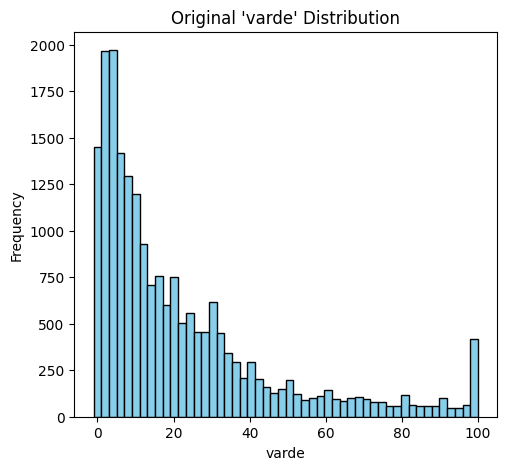

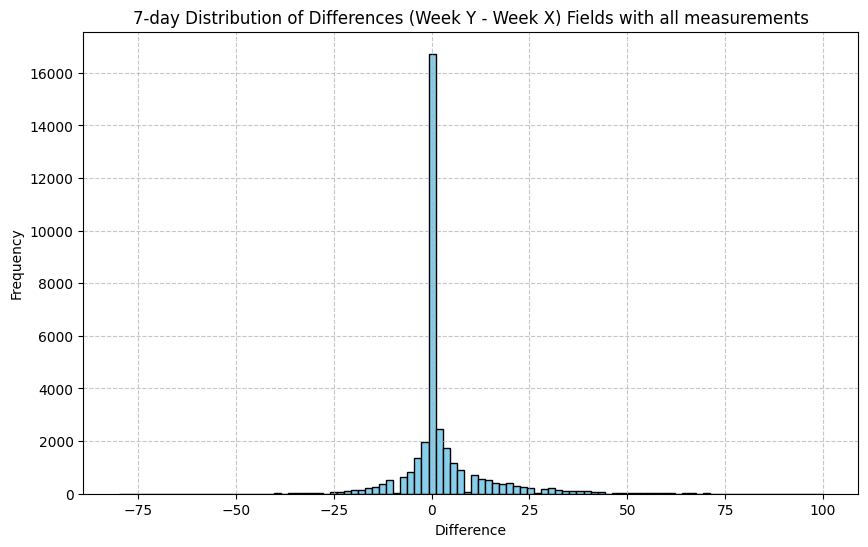

41377
20403


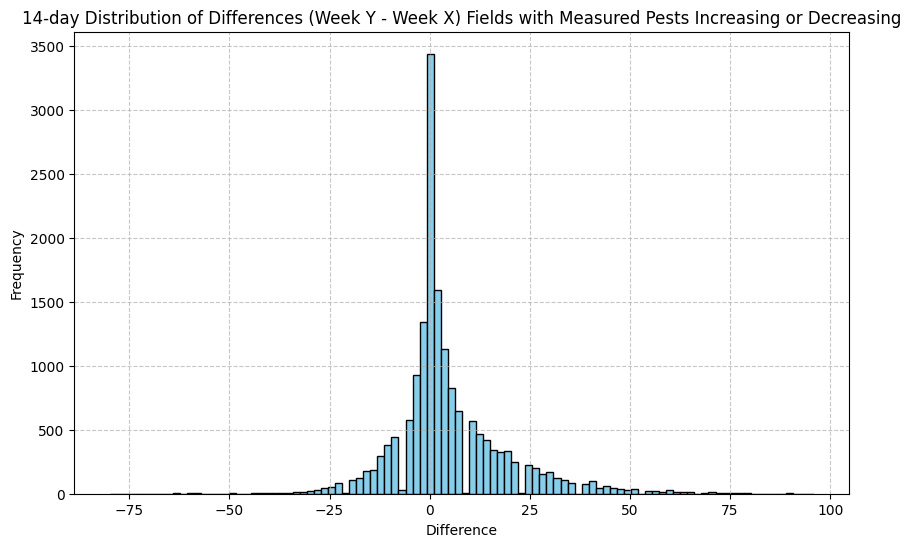

In [4]:


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("aggregated.csv")


print(df.shape[0])
df = df[(df['prevarde'] != 0) & (df['varde'] != 0)]
print(df.shape[0])
# 2.plot the original distribution of 'varde'
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(df['varde'], bins=50, color='skyblue', edgecolor='black')
plt.title("Original 'varde' Distribution")
plt.xlabel('varde')
plt.ylabel('Frequency')

plt.show()
"""
# 3. Filter out rows with 'prevarde' == -1
df = df[df['prevarde'] != -1]

plt.subplot(1, 2, 1)
plt.hist(df['varde'], bins=50, color='skyblue', edgecolor='black')
plt.title("Original 'varde' Distribution")
plt.xlabel('varde')
plt.ylabel('Frequency')

plt.show()
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


df = pd.read_csv("aggregated.csv")

#filter out rows with 'prevarde' equal to -1
df_filtered = df[df['prevarde'] != -1].copy()

#calculate the difference
df_filtered['diff'] = df_filtered['varde'] - df_filtered['prevarde']

#plot the distribution of the differences
plt.figure(figsize=(10, 6))
plt.hist(df_filtered['diff'], bins=100, color='skyblue', edgecolor='black')
plt.title("7-day Distribution of Differences (Week Y - Week X) Fields with all measurements")
plt.xlabel('Difference')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.7)

plt.show()


# Load your data
df = pd.read_csv("aggregated.csv")
print(df.shape[0])
df = df[(df['prevarde'] != 0) & (df['varde'] != 0)]
print(df.shape[0])
# Filter out rows with 'prevarde' equal to -1
df_filtered = df[df['prevarde'] != -1].copy()

# Calculate the difference
df_filtered['diff'] = df_filtered['varde'] - df_filtered['prevarde']

# Plot the distribution of the differences
plt.figure(figsize=(10, 6))
plt.hist(df_filtered['diff'], bins=100, color='skyblue', edgecolor='black')
plt.title("14-day Distribution of Differences (Week Y - Week X) Fields with Measured Pests Increasing or Decreasing")
plt.xlabel('Difference')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.7)

plt.show()


#MODELS

## RF with SICKIT Learn (NOT USED)

Training the mode

With just Temperature:
Mean Squared Error: 238.0987176503226  

sqrt on Mean Squared Error: 15 so on average off by 15


R² Score: 0.5149548862748499

much better random forest (aggregated.csv) with prevarde

Mean Squared Error: 126.52754716592398
R² Score: 0.7367834675386312


RECORD: (WITH UTVECKLINGSSTADIUM)

Mean Squared Error: 116.87101645285674
R² Score: 0.7568720457718526




In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

df = pd.read_csv('aggregated.csv')
df = df[df['prevarde'] != -1]
print("Columns:", df.columns)

#use feature columns ending with "max", "min", "avg", "sum"
feature_cols = [col for col in df.columns if col.endswith(("max", "min", "avg", "sum"))]
#add extra features
feature_cols += ['prevarde']
feature_cols += ['ekologisk']
#feature_cols += ['forfrukt']
#feature_cols += ['utvecklingsstadium']  BIAS Should get pre-utvecklingsstadium

X = df[feature_cols]

#X = pd.get_dummies(X, columns=["forfrukt"], drop_first=True)

y = df['varde']

#split the data into training and testing sets (70% train, 30% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

#train a Random Forest Regressor with default parameters
rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)

#predict on the test set
y_pred = rf.predict(X_test)

#evaluate performance: mean squared error and R² score
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print("Mean Squared Error:", mse)
print("R² Score:", r2)

#calculate correlations between each feature and the target
correlations = {}
for col in X.columns:
    correlations[col] = X[col].corr(y)

#print feature importances with a sign based on correlation
importances = rf.feature_importances_
for name, importance in zip(X.columns, importances):
    sign = '+' if correlations[name] >= 0 else '-'
    print(f"{name}: {sign}{importance:.6f} (corr: {correlations[name]:.3f})")


Columns: Index(['Day1_Morning_Humidity_avg', 'Day1_Morning_Humidity_min',
       'Day1_Morning_Humidity_max', 'Day1_Morning_Soil_Moisture_avg',
       'Day1_Morning_Wind_avg', 'Day1_Morning_Wind_min',
       'Day1_Morning_Wind_max', 'Day1_Morning_Sunshine_duration_sum',
       'Day1_Evening_Humidity_avg', 'Day1_Evening_Humidity_min',
       ...
       'Day8_Evening_Wind_min', 'Day8_Evening_Wind_max',
       'Day8_Evening_Sunshine_duration_sum', 'record_date', 'recordId',
       'graderingId', 'forfrukt', 'prevarde', 'prevutvecklingsstadium',
       'varde'],
      dtype='object', length=158)


KeyError: "['ekologisk'] not in index"

##XGBoost RF (USED ) Best Performer
So we can put it on the GPU and avoid waiting decades

Record:
Mean Squared Error: 107.63456351356754
R² Score: 0.7948394484624113

In [10]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
from xgboost import XGBRegressor

# Load the dataset

df = pd.read_csv('aggregated.csv')
print("Antal rader före filtrering:", df.shape[0])
print("Columns:", df.columns)

print(df.iloc[0].to_string())

#time.sleep(999999)
# Ta bort rader där 'prevarde' är -1
df = df[df['prevarde'] != -1]
df = df[(df['prevarde'] != 0) & (df['varde'] != 0)]



#print(df.iloc[400].to_string())
#time.sleep(999999)


print("Antal rader efter filtrering:", df.shape[0])

print(df.columns)
#time.sleep(999999)
# Use feature columns ending with "max", "min", "avg", "sum"
feature_cols = [col for col in df.columns if col.endswith(("max", "min", "avg", "sum", "diff", "total","temperature","humidity","wind","sunshine"))]
# Add extra features
feature_cols += ['prevarde']
feature_cols += ['prevutvecklingsstadium']
#feature_cols += ['sgu_jordart']
#feature_cols += ['ekologisk']
#feature_cols += ['forfrukt']
# Note: 'utvecklingsstadium' is commented out since BIAS should get pre-utvecklingsstadium

X = df[feature_cols]

# One-hot encode "forfrukt"
#X = pd.get_dummies(X, columns=["forfrukt"], drop_first=True)
#X = pd.get_dummies(X, columns=["sgu_jordart"], drop_first=True)

#print(X.iloc[0].to_string())
#time.sleep(99999999)
print("Columns:", X.columns)

y = df['varde']

#stupid jordarts typer
def clean_column_name(col):
    col = col.replace("<", "less")
    col = col.replace(">", "greater")
    col = col.replace("[", "").replace("]", "")
    return col
X.columns = [clean_column_name(col) for col in X.columns]



#shuffle =  False for window evaluation
#the data is already sorted chronologically
# Split the data into training and testing sets (70% train, 30% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, shuffle=True, random_state=42
)


# Train an XGBoost Regressor using GPU acceleration
# tree_method 'gpu_hist' leverages the GPU for training.
xgb_model = XGBRegressor(tree_method='gpu_hist', random_state=42)
xgb_model.fit(X_train, y_train)

# Predict on the test set
y_pred = xgb_model.predict(X_test)

# Evaluate performance: mean squared error and R² score

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print("Mean Absolute Error:", mae)
print("R² Score:", r2)
# Calculate the standard deviation of the target values in the test set
std_dev = y_test.std()
print("Standard Deviation of y_test:", std_dev)
# Calculate and print the ratio of MAE to standard deviation
ratio = mae / std_dev
print("Ratio of MAE to Standard Deviation:", ratio)


#for metrics purposes
df_train = df.loc[X_train.index].copy()
df_test = df.loc[X_test.index].copy()
df_train["diff"] = df_train["varde"] - df_train["prevarde"]
baseline_avg_diff = df_train["diff"].mean()
baseline_prediction = df_test['prevarde'] + baseline_avg_diff
baseline_mae = mean_absolute_error(df_test['varde'], baseline_prediction)
print("Baseline MAE:", baseline_mae)

baseline_ratio = baseline_mae / std_dev
print("Ratio of Baseline MAE to Standard Deviation:", baseline_ratio)

baseline_mse = mean_squared_error(df_test['varde'], baseline_prediction)
model_mse = mean_squared_error(y_test, y_pred)
print("Baseline MSE:", baseline_mse)
print("Model MSE:", model_mse)


# Calculate correlations between each feature and the target
correlations = {}
for col in X.columns:
    correlations[col] = X[col].corr(y)

# Print feature importances with a sign based on correlation
# Note: XGBoost's feature_importances_ returns non-negative values based on gain.
importances = xgb_model.feature_importances_

for name, importance in zip(X.columns, importances):
    sign = '+' if correlations[name] >= 0 else '-'
    print(f"{name}: {sign}{importance:.6f} (corr: {correlations[name]:.3f})")

from collections import defaultdict

def extract_category(feature_name):
    # Split the name on underscores.
    tokens = feature_name.split('_')
    # Remove the leading day info (e.g. "Day1")
    if tokens[0].startswith("Day"):
        tokens = tokens[1:]
    # Remove the time of day if present ("Morning" or "Evening")
    if tokens and tokens[0] in ["Morning", "Evening"]:
        tokens = tokens[1:]
    # Assume the last token is a summary metric (like avg, min, max, sum, total)
    if len(tokens) > 1:
        category = '_'.join(tokens[:-1])
    else:
        category = tokens[0]
    return category

# Create a dictionary to accumulate importances by category.
category_importance = defaultdict(float)
for name, importance in zip(X.columns, importances):
    category = extract_category(name)
    category_importance[category] += importance

# Print the total summed importance per category.
for cat, total in category_importance.items():
    print(f"{cat}: {total:.6f}")





Antal rader före filtrering: 41377
Columns: Index(['Day1_temperature_avg', 'Day1_temperature_min', 'Day1_temperature_max',
       'Day1_soil_moisture_avg', 'Day1_soil_moisture_min',
       'Day1_soil_moisture_max', 'Day1_humidity_avg', 'Day1_humidity_min',
       'Day1_humidity_max', 'Day1_relative_humidity_avg',
       ...
       'Day8_soil_temp_avg', 'Day8_soil_temp_min', 'Day8_soil_temp_max',
       'Day8_precipitation_sum', 'record_date', 'recordId', 'graderingId',
       'prevarde', 'varde', 'prevutvecklingsstadium'],
      dtype='object', length=190)
Day1_temperature_avg          280.674995
Day1_temperature_min          279.799988
Day1_temperature_max          281.600006
Day1_soil_moisture_avg               NaN
Day1_soil_moisture_min               NaN
Day1_soil_moisture_max               NaN
Day1_humidity_avg               0.004717
Day1_humidity_min                0.00395
Day1_humidity_max                0.00529
Day1_relative_humidity_avg        70.125
Day1_relative_humidity_min 

/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [21:41:01] WARNING: /workspace/src/common/error_msg.cc:27: The tree method `gpu_hist` is deprecated since 2.0.0. To use GPU training, set the `device` parameter to CUDA instead.

    E.g. tree_method = "hist", device = "cuda"

  warnings.warn(smsg, UserWarning)


Mean Absolute Error: 9.961407124008057
R² Score: 0.6712949696566798
Standard Deviation of y_test: 24.045664614591665
Ratio of MAE to Standard Deviation: 0.4142704010752592
Baseline MAE: 10.141161287256288
Ratio of Baseline MAE to Standard Deviation: 0.42174593423807105
Baseline MSE: 201.48318730811755
Model MSE: 190.01785214020754
Day1_temperature_avg: +0.001309 (corr: 0.255)
Day1_temperature_min: +0.001952 (corr: 0.320)
Day1_temperature_max: +0.002216 (corr: 0.190)
Day1_soil_moisture_avg: +0.001536 (corr: 0.092)
Day1_soil_moisture_min: +0.003234 (corr: 0.090)
Day1_soil_moisture_max: +0.003147 (corr: 0.095)
Day1_humidity_avg: +0.002793 (corr: 0.323)
Day1_humidity_min: +0.005400 (corr: 0.327)
Day1_humidity_max: +0.005483 (corr: 0.318)
Day1_relative_humidity_avg: +0.004495 (corr: 0.111)
Day1_relative_humidity_min: +0.002605 (corr: 0.096)
Day1_relative_humidity_max: +0.004342 (corr: 0.114)
Day1_wind_avg: +0.002389 (corr: 0.113)
Day1_wind_min: +0.003513 (corr: 0.127)
Day1_wind_max: +0.0040

/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [21:41:02] WARNING: /workspace/src/common/error_msg.cc:27: The tree method `gpu_hist` is deprecated since 2.0.0. To use GPU training, set the `device` parameter to CUDA instead.

    E.g. tree_method = "hist", device = "cuda"

  warnings.warn(smsg, UserWarning)


Just playing around with a neural net, feel free to do changes

## Neural Net


["humidity", "temperature", "wind", "sunshine"]

Bladfläcksvampar all crops
Aggregate Experiment 1

Mean Absolute Error: 7.607128189159139

R² Score: 0.7715626872216247

Standard Deviation of y_test: 24 ,251702096004806

Ratio of MAE to Standard Deviation: 0.313673991171627

Baseline MAE: 9.839459150589411

Baseline MSE: 202.9335724134321

Model MSE: 134.31459643703852

neural net 1024-512-256-128-128....



In [9]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

print("GPUs Available:", tf.config.list_physical_devices('GPU'))

df = pd.read_csv('aggregated.csv')
print("Antal rader före filtrering:", df.shape[0])
print("Columns:", df.columns)

print(df.iloc[100].to_string())


# Ta bort rader där 'prevarde' är -1
df = df[df['prevarde'] != -1]
df = df[(df['prevarde'] != 0) & (df['varde'] != 0)]
print("Antal rader efter filtrering:", df.shape[0])

#rill missing values with 0
df.fillna(0, inplace=True)

#df['ekologisk'] = df['ekologisk'].astype(int)


# eefine features and target (exclude meta-data columns)
feature_cols = [col for col in df.columns if col not in [
    'outer_date', 'record_date', 'ekologisk', 'recordId',
    'graderingId', 'varde', 'forfrukt', 'jordart', 'record_date'
]]

X = df[feature_cols]

#X = pd.get_dummies(X, columns=["jordart"], drop_first=True)
#stupid jordarts typer
"""
def clean_column_name(col):
    col = col.replace("<", "less")
    col = col.replace(">", "greater")
    col = col.replace("[", "").replace("]", "")
    return col
X.columns = [clean_column_name(col) for col in X.columns]
"""

y = df['varde']

#use df["record_date"] to split rollin_window YYYY-MM-DD it is as string

#split the data
#SHUFFLE = FALSE, for window evaluation
#the data is sorted already
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False, random_state=42
)

# scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# build the neural network model

model = Sequential([
    Dense(1024, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dense(512, activation='relu'),
    Dense(256, activation='relu'),
    Dense(128, activation='relu'),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(1)  #output layer for regression!!!
])

"""
model = Sequential([
    Dense(64, activation='leaky_relu', input_shape=(X_train_scaled.shape[1],)),
    Dense(32, activation='leaky_relu'),
    Dense(16, activation='leaky_relu'),
    Dense(1)  # Output layer for regression
])
"""

optimizer = tf.keras.optimizers.Adam(learning_rate=0.00001) #0.00001
model.compile(optimizer=optimizer, loss='mean_absolute_error')
model.summary()


"""
history = model.fit(
    X_train_scaled,
    y_train,
    #sample_weight=train_weights,
    epochs=200,
    batch_size=32,
    validation_split=0.2
)"""
with tf.device('/GPU:0'):
    history = model.fit(
        X_train_scaled,
        y_train,
        epochs=500,
        #sample_weight=train_weights,
        batch_size=1000,
        validation_split=0.2
    )


y_pred = model.predict(X_test_scaled).flatten()

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print("Mean Absolute Error:", mae)
print("R² Score:", r2)
#calculate the standard deviation of the target values in the test set
std_dev = y_test.std()
print("Standard Deviation of y_test:", std_dev)
#calculate and print the ratio of MAE to standard deviation
ratio = mae / std_dev
print("Ratio of MAE to Standard Deviation:", ratio)


#for metrics purposes
#USED TO COMPARE WITH THE NAIVE BASELINE
df_train = df.loc[X_train.index].copy()
df_test = df.loc[X_test.index].copy()
df_train["diff"] = df_train["varde"] - df_train["prevarde"]
baseline_avg_diff = df_train["diff"].mean()
baseline_prediction = df_test['prevarde'] + baseline_avg_diff
r2_baseline = r2_score(df_test['varde'], baseline_prediction)
print("R2 Baseline: ", r2_baseline)
baseline_mae = mean_absolute_error(df_test['varde'], baseline_prediction)
print("Baseline MAE:", baseline_mae)

baseline_mse = mean_squared_error(df_test['varde'], baseline_prediction)
model_mse = mean_squared_error(y_test, y_pred)
print("Baseline MSE:", baseline_mse)
print("Model MSE:", model_mse)


GPUs Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Antal rader före filtrering: 41377
Columns: Index(['Day1_temperature_avg', 'Day1_temperature_min', 'Day1_temperature_max',
       'Day1_soil_moisture_avg', 'Day1_soil_moisture_min',
       'Day1_soil_moisture_max', 'Day1_humidity_avg', 'Day1_humidity_min',
       'Day1_humidity_max', 'Day1_relative_humidity_avg',
       ...
       'Day8_soil_temp_avg', 'Day8_soil_temp_min', 'Day8_soil_temp_max',
       'Day8_precipitation_sum', 'record_date', 'recordId', 'graderingId',
       'prevarde', 'varde', 'prevutvecklingsstadium'],
      dtype='object', length=190)
Day1_temperature_avg          281.575005
Day1_temperature_min          278.200012
Day1_temperature_max          285.100006
Day1_soil_moisture_avg           0.26325
Day1_soil_moisture_min             0.261
Day1_soil_moisture_max             0.267
Day1_humidity_avg               0.003898
Day1_humidity_min                0.00331
Day1_humidity_max         

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_45 (Dense)                     │ (None, 1024)                │         191,488 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_46 (Dense)                     │ (None, 512)                 │         524,800 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_47 (Dense)                     │ (None, 256)                 │         131,328 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_48 (Dense)                     │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_49 (Dense)                     │ (None, 128)                 │          16,512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_50 (Dense)                     │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_51 (Dense)                     │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_52 (Dense)                     │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_53 (Dense)                     │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 907,905 (3.46 MB)

 Trainable params: 907,905 (3.46 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/500
11/11 ━━━━━━━━━━━━━━━━━━━━ 5s 161ms/step - loss: 23.0594 - val_loss: 23.7810
Epoch 2/500
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 22.5753 - val_loss: 23.7200
Epoch 3/500
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 22.9297 - val_loss: 23.6565
Epoch 4/500
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 22.9005 - val_loss: 23.5867
Epoch 5/500
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 22.8148 - val_loss: 23.5075
Epoch 6/500
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 22.4275 - val_loss: 23.4149
Epoch 7/500
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 22.9458 - val_loss: 23.3087
Epoch 8/500
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 22.8111 - val_loss: 23.1853
Epoch 9/500
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 22.6592 - val_loss: 23.0432
Epoch 10/500
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 22.5313 - val_loss: 22.8744
Epoch 11/500
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 21.6645 - val_loss: 22.6752
Epoch 12/500
11/11 ━━━━━━━━━━